# 10 - Pixel-space generative prior (score-based DA)

An unconditional diffusion model trained on the LOVECLIM anomaly fields replaces
the Gaussian background of 3DVar. Reconstruction is guided posterior sampling: the
EDM reverse process plus an observation-guidance score
`grad log p(y | x_sigma) = -0.5 (y - H x_hat)^T V^-1 (y - H x_hat)`, with
`V = R + sigma^2 gamma` and `x_hat = D(x_sigma; sigma)` (Manshausen et al. 2025;
Rozet and Louppe 2023; Chung et al. 2023).

Two priors mirror the compressors: the older chronological half for the same-model
PPE lane, all ages for the withholding lane. `gamma` (the likelihood inflation) is
the tuned operating point, selected on the held-out split and reported on the test
split, so results land in `outputs/da/generative/` on the same schema notebook 09
compares.

In [1]:
%load_ext autoreload
%autoreload 2

import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.cube import apply_anomaly, compute_zscore_stats
from paleoreco.data.splits import chronological_half_split
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.models.diffusion import CircularUNet, EDMDenoiser, SIGMA_DATA
from paleoreco.training import trainer_diffusion as td
from paleoreco.assim.generative import GuidedSampler, channel_scales
from paleoreco.assim import experiments_generative as gex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
CKPT = Path("../outputs/checkpoints/10_generative_prior")
FIG = Path("../outputs/figures/10_generative_prior")
CKPT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Prior cube, chronological split, and the two normalised anomaly frames

Each frame is the per-cell anomaly over its own ages, rescaled per channel to std
`SIGMA_DATA`, the scale the EDM recipe expects. The states, the climatology and the
scaling scalars all come from those ages, so the PPE prior never sees the younger
truths.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

TRUTH_STRIDE = 10
all_idx = np.arange(len(ages))
prior_idx, truth_idx = chronological_half_split(ages, stride=TRUTH_STRIDE)

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))


def frame(idx):
    """safe_valid mask, per-channel scales, and the SIGMA_DATA-scaled anomaly cube over ``idx``.

    The cube is restricted to ``idx`` after centring, so the states, the climatology
    and the scaling scalars all come from the same ages.
    """
    stats = compute_zscore_stats(cube, idx, valid)
    anom = apply_anomaly(cube, stats)[idx]
    scales = channel_scales(anom, stats["safe_valid"])
    norm = anom * (SIGMA_DATA / scales)[None, :, None, None]
    return stats["safe_valid"], scales, anom.astype(np.float64), norm.astype(np.float32)


safe_a, scales_a, anom_a, norm_a = frame(prior_idx)   # older half -> PPE prior
safe_all, scales_all, anom_all, norm_all = frame(all_idx)  # all ages -> withholding prior
print("cube", cube.shape, "| prior states", norm_a.shape[0], "| all states", norm_all.shape[0],
      "| sites", long_ppe["site"].nunique())
print("channel scales (older/all):", np.round(scales_a, 3), np.round(scales_all, 3))

cube (804, 2, 32, 64) | prior states 402 | all states 804 | sites 187
channel scales (older/all): [1.362 0.972] [1.427 1.461]


## Train the two diffusion priors

Small U-Net, EDM denoising-score-matching with EMA. Data is scarce (hundreds of
autocorrelated states), so the epoch count is selected rather than fixed: each lane
first *searches* on a random 75/25 split, stopping once the held-out score has not
improved for `PATIENCE` epochs, then *refits* on every state up to the best epoch.

The held-out score is the EDM loss on a fixed grid of noise levels with fixed noise,
not the training loss: the training loss draws a random noise level per sample, and
that spread is far larger than the epoch-to-epoch change early stopping has to
resolve. It scores the EMA weights, since those are what the checkpoint saves and
the sampler loads.

The refit keeps the cosine horizon at `EPOCHS`, so it follows the same learning-rate
trajectory the search selected on and the chosen epoch keeps its meaning. Set
`RETRAIN = False` once the checkpoints exist to skip both phases.

In [3]:
RETRAIN = True
EPOCHS, BASE, DEPTH, LR, BATCH = 3000, 64, 2, 2e-4, 64
VAL_FRACTION, PATIENCE, SPLIT_SEED = 0.25, 50, 0
T0 = time.time()


def _net():
    return EDMDenoiser(CircularUNet(base_channels=BASE, depth=DEPTH,
                                    grid_shape=tuple(cube.shape[2:])))


def train_prior(norm, safe, scales, path, lane, step):
    """Select the epoch count on a held-out split, then refit on every state."""
    if path.exists() and not RETRAIN:
        print("exists:", path.name)
        return None

    perm = np.random.default_rng(SPLIT_SEED).permutation(len(norm))
    n_val = int(round(VAL_FRACTION * len(norm)))
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    print(f"[{step}/4] {lane} search | {len(train_idx)} train / {len(val_idx)} val "
          f"| max {EPOCHS} ep, patience {PATIENCE}", flush=True)
    t = time.time()
    search = td.train(_net(), norm[train_idx], safe, val_cube=norm[val_idx],
                      patience=PATIENCE, max_epochs=EPOCHS, batch_size=BATCH,
                      lr=LR, device=DEVICE, seed=0)
    n_star = search["best_epoch"] + 1          # 0-based index -> epoch count
    print(f"[{step}/4] {lane} search | done in {time.time() - t:.0f}s "
          f"| best ep {search['best_epoch']} | stopped at {search['stop_epoch']} "
          f"| early={search['stopped_early']} | refit to {n_star}", flush=True)

    print(f"[{step + 1}/4] {lane} refit | {n_star} ep on {len(norm)} states", flush=True)
    t = time.time()
    td.train(_net(), norm, safe, max_epochs=n_star, lr_schedule_epochs=EPOCHS,
             batch_size=BATCH, lr=LR, device=DEVICE, checkpoint_path=str(path),
             channel_scales=scales, seed=0,
             checkpoint_extra={"selection": {
                 "best_epoch": int(search["best_epoch"]),
                 "stop_epoch": int(search["stop_epoch"]),
                 "refit_epochs": int(n_star),
                 "stopped_early": bool(search["stopped_early"]),
                 "patience": int(PATIENCE), "val_fraction": float(VAL_FRACTION),
                 "split_seed": int(SPLIT_SEED), "max_epochs": int(EPOCHS)}})
    print(f"[{step + 1}/4] {lane} refit | done in {time.time() - t:.0f}s "
          f"| wrote {path.name}", flush=True)

    np.savez(CKPT / f"{path.stem}_search.npz",
             **{k: np.asarray(v) for k, v in search["history"].items()})
    return search


search_a = train_prior(norm_a, safe_a, scales_a, CKPT / "diffusion_chunkA.pt", "chunkA", 1)
search_all = train_prior(norm_all, safe_all, scales_all, CKPT / "diffusion_full.pt", "full", 3)
print(f"total {time.time() - T0:.0f}s")

[1/4] chunkA search | 302 train / 100 val | max 3000 ep, patience 50


diffusion:   0%|          | 1/3000 [00:02<2:28:22,  2.97s/ep, loss=0.9581, val=0.8606, best=0.8606, wait=0, s/ep=3.0]

epoch    0  loss=0.9581  val=0.8606  best=0.8606@0  lr=2.00e-04  (3.0s)


diffusion:   2%|▏         | 51/3000 [01:29<1:33:42,  1.91s/ep, loss=0.1879, val=0.2827, best=0.2827, wait=0, s/ep=2.2]

epoch   50  loss=0.1879  val=0.2827  best=0.2827@50  lr=2.00e-04  (2.2s)


...

diffusion:  98%|█████████▊| 1601/1631 [38:38<00:43,  1.44s/ep, loss=0.0615, s/ep=1.4]

epoch 1600  loss=0.0615  lr=8.95e-05  (1.4s)


diffusion: 100%|██████████| 1631/1631 [39:21<00:00,  1.45s/ep, loss=0.0600, s/ep=1.5]

[4/4] full refit | done in 2362s | wrote diffusion_full.pt


total 10280s


### Search curves

Red marks where early stopping halted the search, grey the best epoch the refit used.
On the left all three curves are the same fixed-grid score, so the gap between the
training probe and the held-out curve is the generalisation gap, and the gap between
the EMA and live curves is the lag introduced by weight averaging. The right panel is
the random-sigma quantity actually minimised, which sits on its own scale.

If the probe and held-out curves sit on top of each other and never separate, the
random split has no detection power on states this autocorrelated, and the result is
inconclusive rather than evidence of no overfitting.

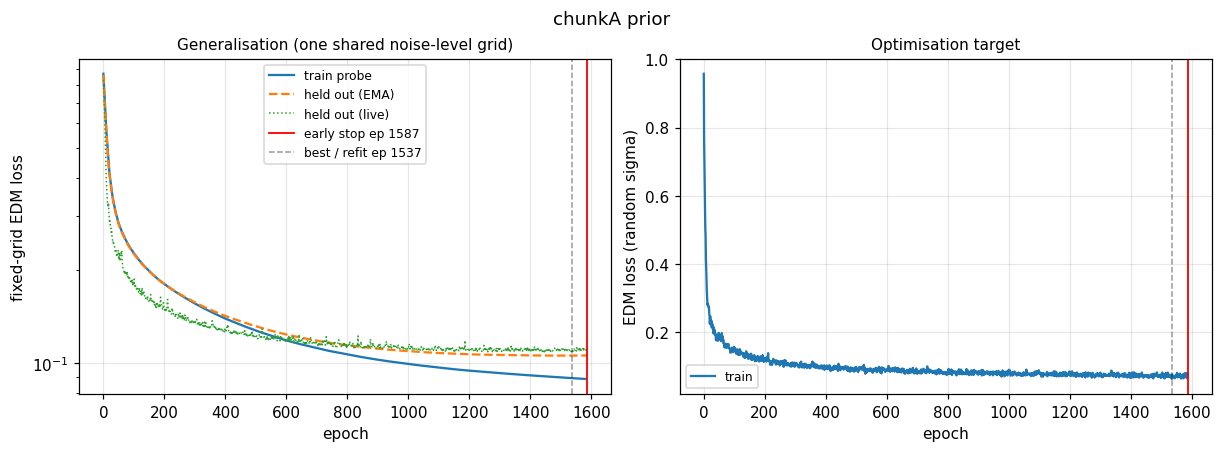

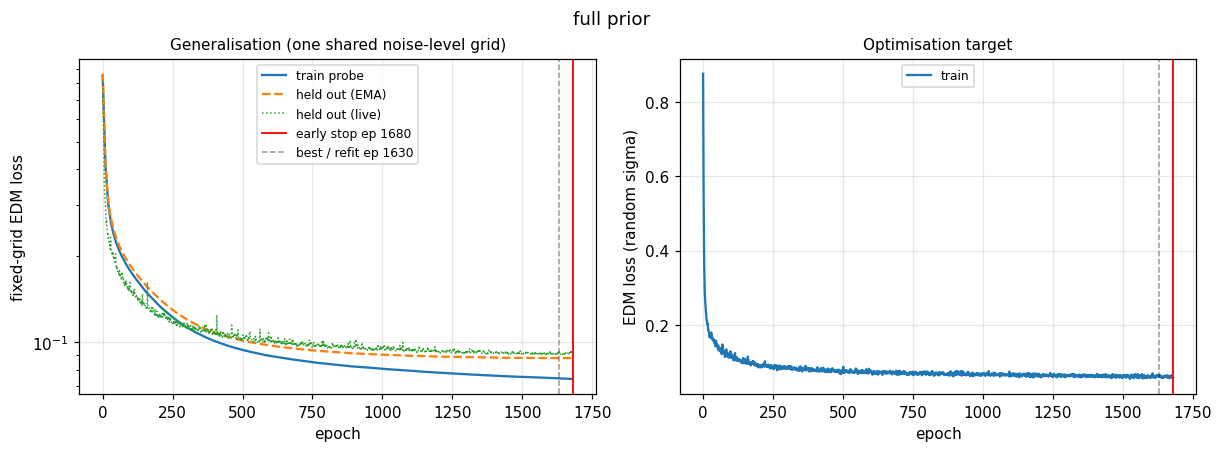

In [4]:
from paleoreco.eval.diffusion import plot_loss_curves_diffusion

for lane, search in (("chunkA", search_a), ("full", search_all)):
    if search is None:
        continue
    plot_loss_curves_diffusion(
        search["history"], best_epoch=search["best_epoch"],
        stop_epoch=search["stop_epoch"] - 1, title=f"{lane} prior",
        save_path=str(FIG / f"loss_curves_{lane}.png"))
    plt.show()

## Build the two samplers

In [5]:
N_STEPS, N_CORRECT, TAU = 64, 2, 0.3
GAMMA_GRID = gex.GAMMA_GRID
K, K_SELECT = 16, 8


def load_sampler(path, safe):
    ckpt = torch.load(path, map_location="cpu")
    net = EDMDenoiser(CircularUNet(**ckpt["config"]), ckpt["sigma_data"])
    net.load_state_dict(ckpt["state_dict"])
    return GuidedSampler(net, np.asarray(ckpt["channel_scales"]), safe,
                         n_samples=K, n_steps=N_STEPS, n_correct=N_CORRECT,
                         corrector_tau=TAU, device=DEVICE)


sampler_ppe = load_sampler(CKPT / "diffusion_chunkA.pt", safe_a)
sampler_wh = load_sampler(CKPT / "diffusion_full.pt", safe_all)

## Unconditional sanity: did the prior learn the climate?

Given the small training set, check that generated fields resemble real LOVECLIM
states (per-cell std, leading-PC score spread) and that the model is not
regurgitating training snapshots (nearest-neighbour distance).

median NN distance  generated: 52.036  train: 22.731


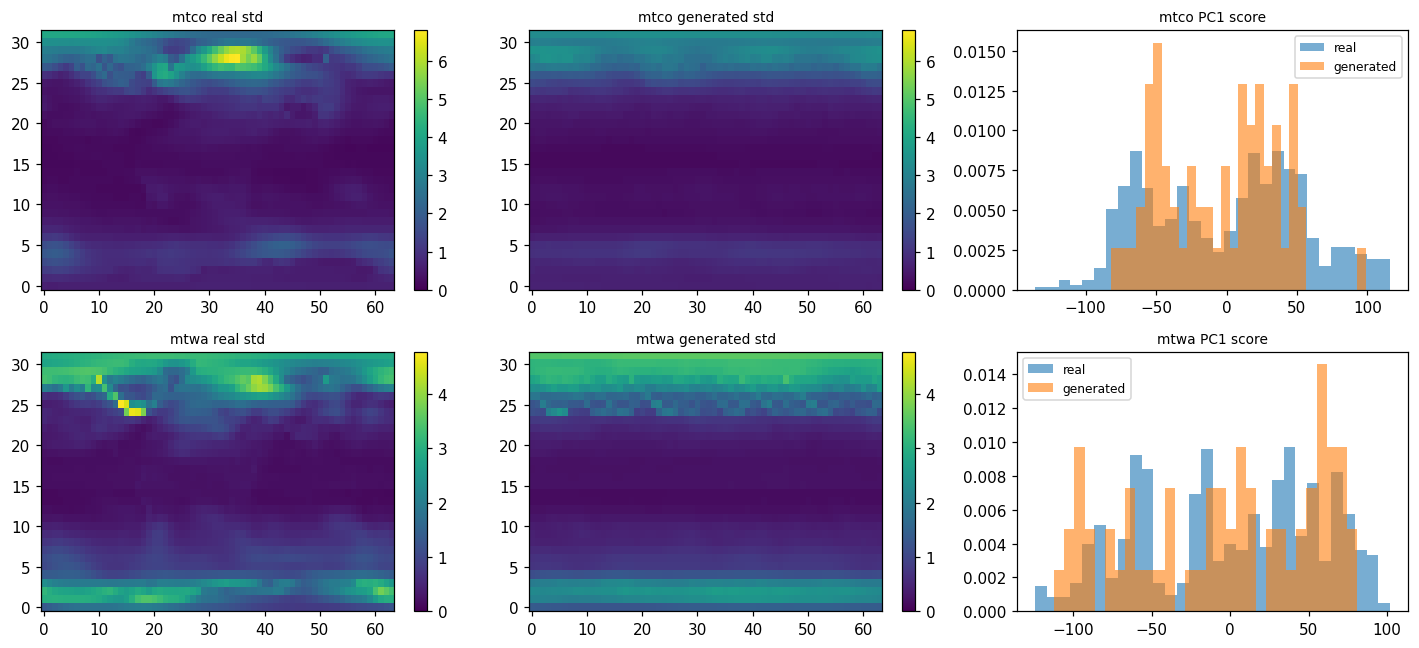

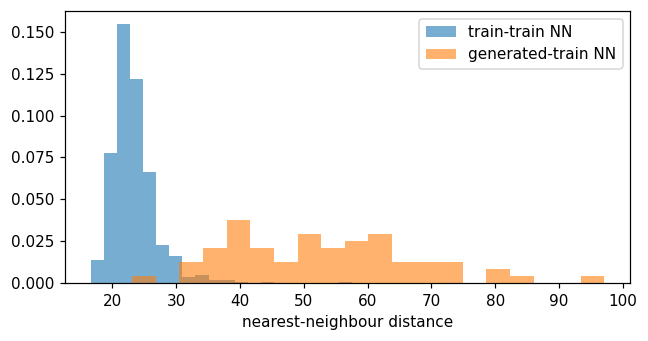

In [6]:
prior_samples = sampler_wh.sample_prior(64, seed=0)   # (64, 2, H, W) anomaly units
gen = prior_samples[:, :, safe_all]
real = anom_all[:, :, safe_all]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for c, name in enumerate(VARS):
    vmax = float(real[:, c].std(0).max())
    for col, (title, field) in enumerate((("real std", real[:, c].std(0)),
                                          ("generated std", gen[:, c].std(0)))):
        m = np.full(safe_all.shape, np.nan); m[safe_all] = field
        ax = axes[c, col]
        im = ax.imshow(m, origin="lower", cmap="viridis", vmin=0, vmax=vmax, aspect="auto")
        ax.set_title(f"{name} {title}", fontsize=9); fig.colorbar(im, ax=ax, fraction=0.046)
    # leading-PC score distribution, generated vs real
    Xr = real[:, c] - real[:, c].mean(0)
    u, s, vt = np.linalg.svd(Xr, full_matrices=False)
    pc = vt[0]
    axes[c, 2].hist((Xr @ pc), bins=30, density=True, alpha=0.6, label="real")
    axes[c, 2].hist(((gen[:, c] - real[:, c].mean(0)) @ pc), bins=30, density=True,
                    alpha=0.6, label="generated")
    axes[c, 2].set_title(f"{name} PC1 score", fontsize=9); axes[c, 2].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "unconditional_quality.png", bbox_inches="tight")

# memorisation: nearest training state for each generated sample vs a train-train baseline.
# cdist avoids the O(N^2 * D) broadcast that would materialise ~20 GB for ~800 states.
from scipy.spatial.distance import cdist

gv = gen.reshape(len(gen), -1)
rv = real.reshape(len(real), -1)
d_gen = cdist(gv, rv).min(1)
dd = cdist(rv, rv); np.fill_diagonal(dd, np.inf)
d_train = dd.min(1)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(d_train, bins=20, density=True, alpha=0.6, label="train-train NN")
ax.hist(d_gen, bins=20, density=True, alpha=0.6, label="generated-train NN")
ax.set_xlabel("nearest-neighbour distance"); ax.legend(); fig.tight_layout()
fig.savefig(FIG / "memorisation.png", bbox_inches="tight")
print("median NN distance  generated:", round(float(np.median(d_gen)), 3),
      " train:", round(float(np.median(d_train)), 3))

## Run the generative lanes

PPE on the older-half prior, withholding on the all-ages prior. `gamma` is swept on
the selection split and reported at its winner on the test split; withholding is
age-subsampled for cost (the stride is recorded in the config). Results share the
`outputs/da/generative/` schema, so notebook 09 compares them against 3DVar.

In [7]:
d = OUT / "generative"
if d.exists():
    shutil.rmtree(d)

gex.run_ppe_generative(
    cube, ages, lats, lons, valid, long_ppe, str(d), sampler=sampler_ppe,
    gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
    truth_stride=TRUTH_STRIDE, progress_every=5)

gex.run_withholding_generative(
    cube, ages, lats, lons, valid, long_wh, str(d), sampler=sampler_wh,
    gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
    fold_kind="random", age_stride=6, progress_every=1)
print("wrote", sorted(p.name for p in d.iterdir()))

  gamma 1/5 (20%, elapsed 183s, eta 732s)
  gamma 2/5 (40%, elapsed 367s, eta 550s)
  gamma 3/5 (60%, elapsed 552s, eta 368s)
  gamma 4/5 (80%, elapsed 729s, eta 182s)
  gamma 5/5 (100%, elapsed 906s, eta 0s)
  truth 5/41 (12%, elapsed 21s, eta 154s)
  truth 10/41 (24%, elapsed 43s, eta 133s)
  truth 15/41 (37%, elapsed 65s, eta 112s)
  truth 20/41 (49%, elapsed 88s, eta 92s)
  truth 25/41 (61%, elapsed 109s, eta 70s)
  truth 30/41 (73%, elapsed 131s, eta 48s)
  truth 35/41 (85%, elapsed 152s, eta 26s)
  truth 40/41 (98%, elapsed 173s, eta 4s)
  gamma (withholding_random) 1/5 (20%, elapsed 2333s, eta 9332s)
  gamma (withholding_random) 2/5 (40%, elapsed 4574s, eta 6861s)
  gamma (withholding_random) 3/5 (60%, elapsed 6636s, eta 4424s)
  gamma (withholding_random) 4/5 (80%, elapsed 8436s, eta 2109s)
  gamma (withholding_random) 5/5 (100%, elapsed 10368s, eta 0s)
  test-fold (withholding_random) 1/5 (20%, elapsed 383s, eta 1530s)
  test-fold (withholding_random) 2/5 (40%, elapsed 776s, e

## Prior vs posterior

The gamma tuning curve (selection RRMSE), the prior-to-posterior variance reduction
(reused from the 3DVar diagnostic), and the pointwise prior/posterior distribution
at a cell near a site and one far from any site.

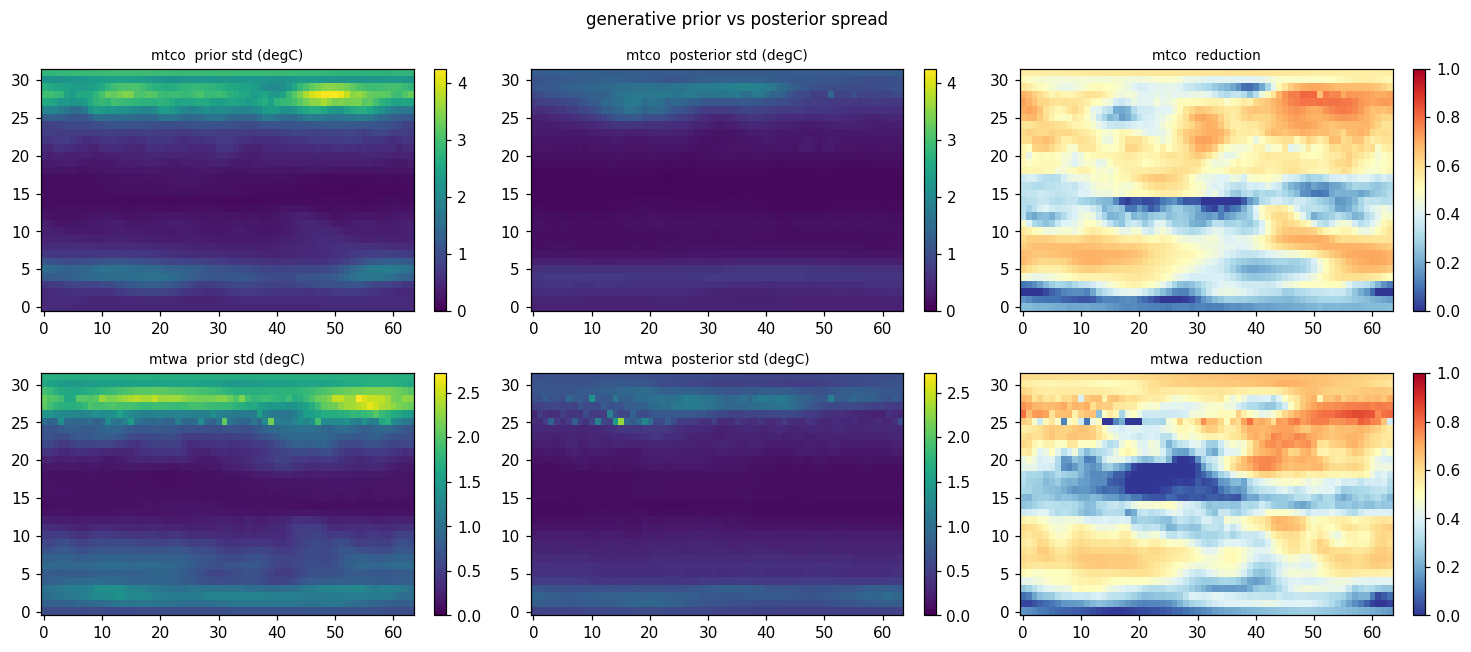

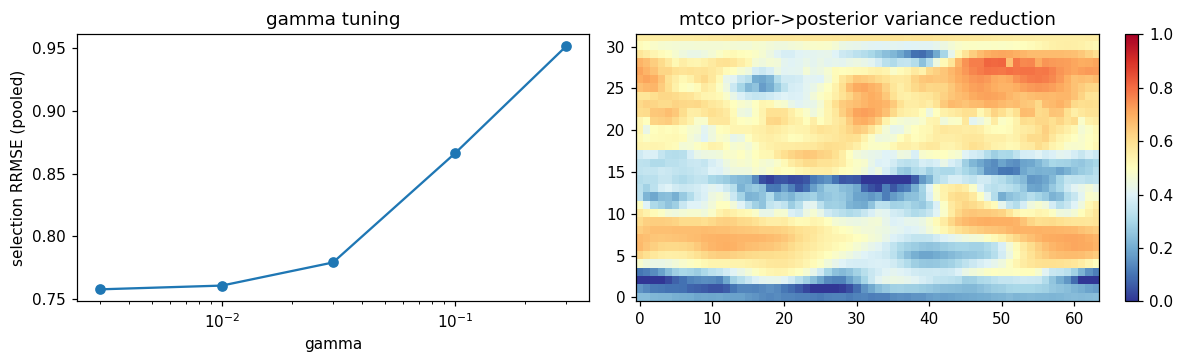

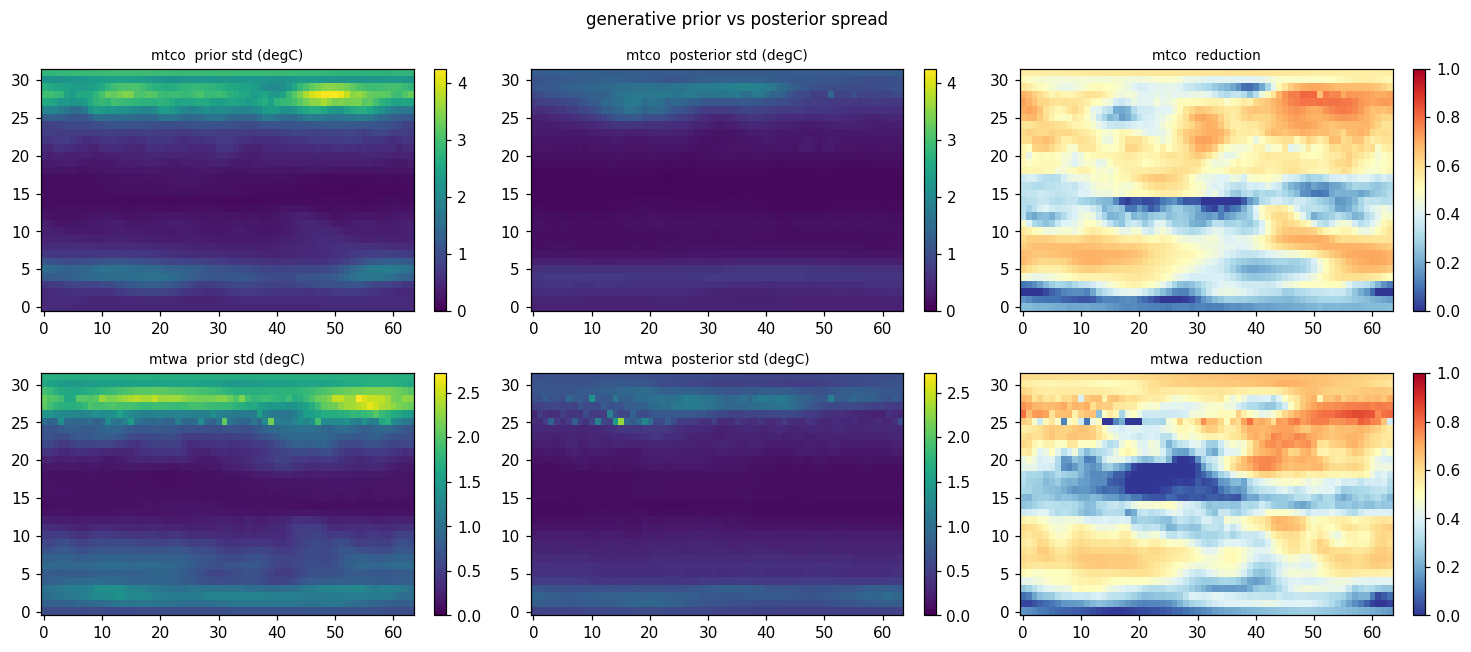

In [8]:
M = pd.read_csv(OUT / "generative" / "metrics.csv")
sel = M[(M.lane == "ppe") & (M.split == "selection") & (M.channel == "pooled")
        & (M.do_event == "all") & (M.metric == "rrmse")].sort_values("b_scale")

z = np.load(OUT / "generative" / "ppe_analysis.npz")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(sel["b_scale"], sel["value"], "o-"); ax[0].set_xscale("log")
ax[0].set_xlabel("gamma"); ax[0].set_ylabel("selection RRMSE (pooled)")
ax[0].set_title("gamma tuning")

red = da.uncertainty_reduction(z["prior_ens_var"], z["post_var"][0].mean(axis=0))
im = ax[1].imshow(np.where(safe_all, red[0], np.nan), origin="lower", cmap="RdYlBu_r",
                  vmin=0, vmax=1, aspect="auto")
ax[1].set_title("mtco prior->posterior variance reduction")
fig.colorbar(im, ax=ax[1], fraction=0.046)
fig.tight_layout(); fig.savefig(FIG / "gamma_and_variance_reduction.png", bbox_inches="tight")

da.plot_prior_posterior_uncertainty(
    z["prior_ens_var"], z["post_var"][0].mean(axis=0), safe_all, VARS,
    title="generative prior vs posterior spread",
    save_path=str(FIG / "uncertainty_reduction_generative.png"))

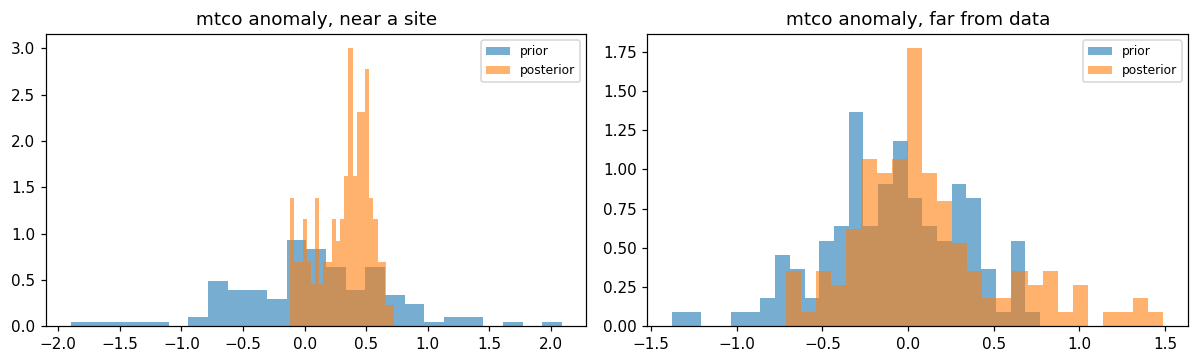

In [9]:
# Pointwise prior vs posterior at a near-site and a far cell (mtco), for one truth.
from paleoreco.assim.observations import observations_at_age
from paleoreco.assim.experiments import _obs_geometry

n_cells = len(lats) * len(lons)
safe_flat = np.broadcast_to(safe_a, (len(VARS), *safe_a.shape)).ravel()
age0 = int(z["drawn_ages"][0, -1])
geom = _obs_geometry(observations_at_age(long_ppe, age0), lats, lons, safe_flat)
truth0 = z["truth_anom"][0]
y0 = truth0.ravel()[geom["gather"]]
gamma_star = float(z["b_scales"][0])
post = sampler_ppe.sample_posterior(geom["gather"], y0, geom["sse"], gamma_star, 128, seed=1)
prior = sampler_ppe.sample_prior(128, seed=2)

# Index the mtco channel (cells 0..n_cells-1) at an observed site and at the void.
near = int(geom["gather"][0]) % n_cells
far = int(np.argmax(da.nearest_obs_distance(lats, lons, geom["lat"], geom["lon"])))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, (cell, label) in zip(ax, ((near, "near a site"), (far, "far from data"))):
    a.hist(prior.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6, label="prior")
    a.hist(post.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6, label="posterior")
    a.set_title(f"mtco anomaly, {label}"); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "pointwise_prior_posterior.png", bbox_inches="tight")

## Reading

The cross-method comparison against 3DVar (skill, calibration, prior-to-posterior,
gallery) lives in `09_da_comparison`, which discovers `outputs/da/generative/`
automatically. Bimodality-recovery near D-O transitions is the next milestone.